# Pushed and Pulled Front Transitions in Tumor Growth (Simulations)


This code is based on the `biolgca` Python Package. Installation instructions and documentation can be found [here](https://github.com/sisyga/biolgca).

### Loading the Packages

In [1]:
#from google.colab import files
#uploaded = files.upload()

#import zipfile
#import os

#zip_file = 'lgca.zip'

#with zipfile.ZipFile(zip_file, 'r') as zip_ref:
#    zip_ref.extractall('/content/lgca')

#import sys
#sys.path.append('/content/lgca')

import lgca


In [2]:
from lgca import get_lgca
import numpy.random as npr
import numpy as np
from bisect import bisect_left
from random import random
import matplotlib.pyplot as plt

### Defining the Functions
We have 2 functions, `random_walk` and `birthdeathae`. The `birthdeathae` function is a custom-made function used as an interaction for the LGCA model to describe birth and death with a nonlinear reaction term.

In [13]:
def random_walk(lgca):
    """
    Shuffle config in the last axis, modeling a random walk.
    :return:
    """
    # disarrange(lgca.nodes, axis=-1)
    relevant = (lgca.cell_density[lgca.nonborder] > 0) & \
               (lgca.cell_density[lgca.nonborder] < lgca.K)
    coords = [a[relevant] for a in lgca.nonborder]
    for coord in zip(*coords):
        npr.shuffle(lgca.nodes[coord])

def birthdeathae(lgca):
    """
    - Birth Death with Allee (Nonlinear) Growth
    Variables:
    - n: Node Density (No. of Cells)
    - rho: Mean-Field Density
    - rb: Birth Rate
    - rd: Death Rate
    - rb_tilde: Mean-Field Birth Rate
    - rd_tilde: Mean-Field Death Rate
    - a: Allee Parameter
    - a_tilde: Mean-Field Allee Parameter
    - I: Indicator Function
    - lgca.K: Carrying Capacity
    :return:
    """
    n = lgca.cell_density[..., None]     # Arbitrary values, between 0,1,2
    # n=np.ones((52,52,1))               # Manually force all n values to be 1 (if needed)
    # n[n > 1] = 1                       # Manually set n=2 values as n=1      (if needed)

    rb = lgca.interaction_params['r_b']
    rd = lgca.interaction_params['r_d']
    rb_tilde = rb#/ lgca.K
    rd_tilde = rd#/ lgca.K
    #rd_tilde = rb_tilde

    rho = n/lgca.K
    a = -1                                # Set manually. In case of values n = 1 (all or some) the threshold is around -2.4
    a_tilde = a/ lgca.K
    #I = np.where((n + a) > 0, 1, 0)
    I = np.heaviside(n+a, 0)

    birth = npr.random(lgca.nodes.shape) < (rb_tilde * (rho)**2 + rb_tilde * (a/lgca.K) * rho * I)#*(1 - rho) # Full description
    death = npr.random(lgca.nodes.shape) < (rd_tilde * (np.abs(a)/lgca.K) * (1-I))*(1 - rho) #/ lgca.K # * rho          # of the model

    ds = (1 - lgca.nodes) * birth - (lgca.nodes) * death            # Tests if cell is full or not. If full, only death takes place

    np.add(lgca.nodes, ds, out=lgca.nodes, casting='unsafe')
    #lgca.update_dynamic_fields()
    random_walk(lgca)

### Simulating for Homogenous Initial Conditions

 For this simulation, we set the initial conditions to homogenous, starting at the value of `density`, on a lattice of dimension `dims`. We simulate for 100 timesteps. Setting the allee parameter to be above around -2.5, we get logistic growth, and setting it around -3 or less, we get an exponential decay.

100%|██████████| 1000/1000 [00:00<00:00, 6207.03it/s]


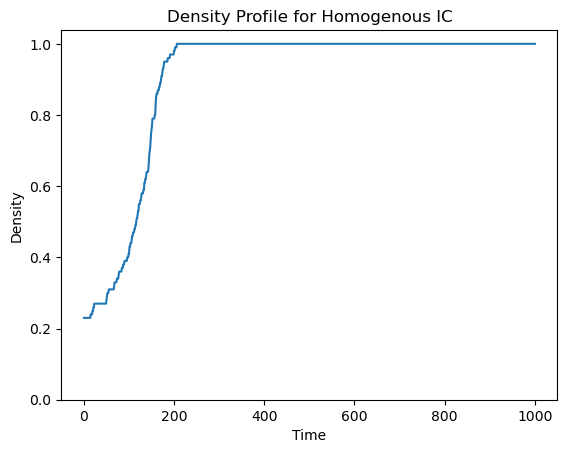

In [9]:
%matplotlib inline

lgca = get_lgca(interaction='birthdeath',geometry='lin', restchannels=98, density=0.2, # n=1
                r_b = 0.1, r_d = 0.1, bc='periodic', dims=(1))
lgca.interaction = birthdeathae

lgca.timeevo(1000,recordN=True)
plt.xlabel('Time')
plt.ylabel('Density')
plt.title('Density Profile for Homogenous IC')
plt.plot(lgca.n_t/lgca.K)
plt.ylim(0)
plt.show()

'### Simulating for Nonhomogenous Initial Conditions
We now opt for a nonhomogenous initial condition where set the initial condition to be a thin strip of cells simulating growth in a tube which is the 400 by 20 lattice. We simulate it for 200 timesteps and plot the density profile.

100%|██████████| 2000/2000 [00:07<00:00, 269.29it/s]


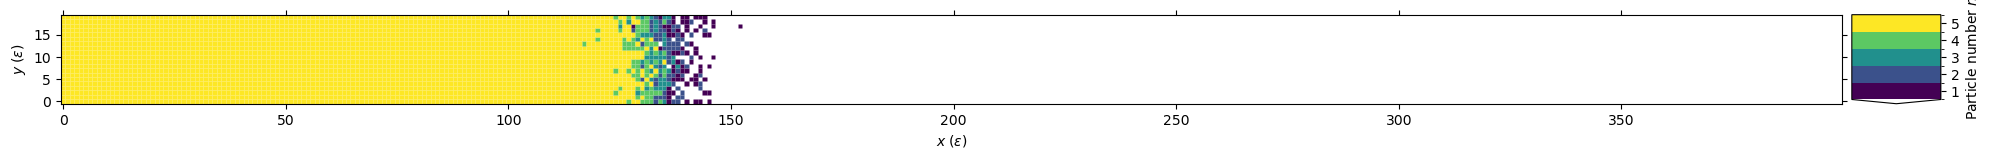

In [15]:
%matplotlib inline
nodes = np.zeros((400, 20, 5))
nodes[0:2, 0:21, :] = 1

lgca = get_lgca(interaction='birthdeath',geometry='square', restchannels=1, nodes=nodes,
                r_b = 0.1, r_d = 0.1, bc='refl', dims=(400,20))
lgca.interaction = birthdeathae

lgca.timeevo(timesteps=2000, record=True)
fig, patch_collection, scalar_mappable = lgca.plot_density()
fig.set_size_inches(20, 17)
plt.show()

### Projecting the Simulation onto the X-Axis (1D Simulation)

To project the model on the x-axis and get 1D simulations, we average over the y-axis. We set the initial conditions to be a strip of cells just like the previous simulation. We simulate it for 1000 timesteps.

100%|██████████| 1000/1000 [00:03<00:00, 275.42it/s]


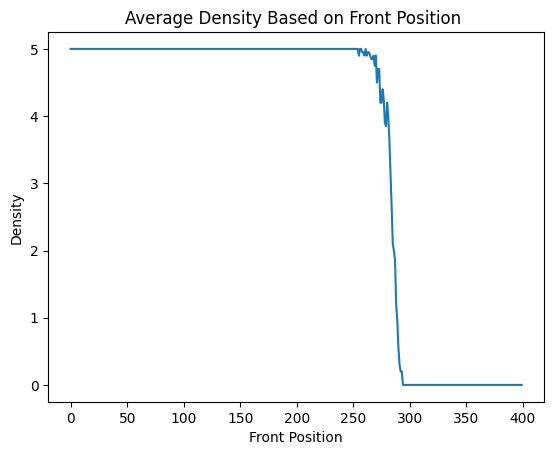

In [ ]:
%matplotlib inline
#nodes = np.zeros((400, 20, 5))
#nodes[0:2, 0:21, :] = 1

#lgca = get_lgca(interaction='birthdeath',geometry='square', restchannels=1, nodes=nodes, # n=1
#                r_b = 1, r_d = 0.5, bc='refl', dims=(400,20))
#lgca.interaction = birthdeathae

lgca.timeevo(timesteps=1000, record=True, recorddens=True)
average_dens = np.mean(lgca.dens_t, axis=-1) #lgca.dens_t: (time, x, y)

plt.xlabel('Front Position')
plt.ylabel('Density')
plt.title('Average Density Based on Front Position ')
plt.plot(average_dens[-1]) #(-1 is the last index)
plt.show()


The x-axis corresponds to the front position and we notice that in the middle, the density is equal to 5 (full node) which coincides with our initial condition.

### Repeating the Simulations and Taking the Average

We will now repeat the simulations 2 times (normally 10 times but for now i'll keep it 2 to avoid overworking my laptop), and take their average in order to reduce the noise.

100%|██████████| 1000/1000 [00:04<00:00, 214.66it/s]


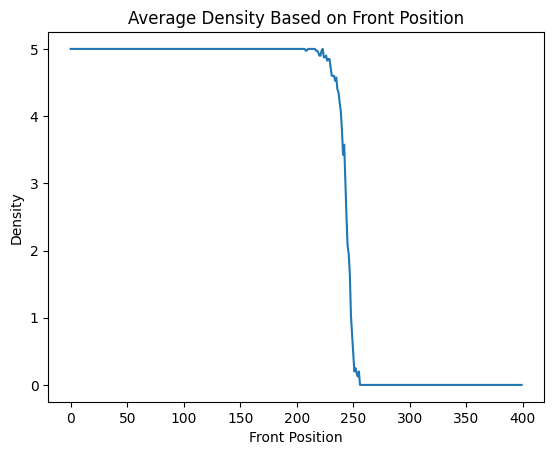

In [ ]:
num_simulations = 2
average_densities = []

for _ in range(num_simulations):
    nodes = np.zeros((400, 20, 5))
    nodes[0:2, 0:21, :] = 1
    lgca = get_lgca(interaction='birthdeath',geometry='square', restchannels=1, nodes=nodes, # n=1
                r_b = 1, r_d = 0.5, bc='refl', dims=(400,20))
    lgca.interaction = birthdeathae
    lgca.timeevo(timesteps=1000, record=True, recorddens=True)
    average_dens = np.mean(lgca.dens_t, axis=-1)
    average_densities.append(average_dens)

average_densities = np.stack(average_densities, axis=-1)
average_density_avg = np.mean(average_densities, axis=-1)

plt.xlabel('Front Position')
plt.ylabel('Density')
plt.title('Average Density Based on Front Position')
plt.plot(average_density_avg[-1])
plt.show()


### Calculating the Front Speed

We calculate the front speed by plotting the time evolution of the front position.

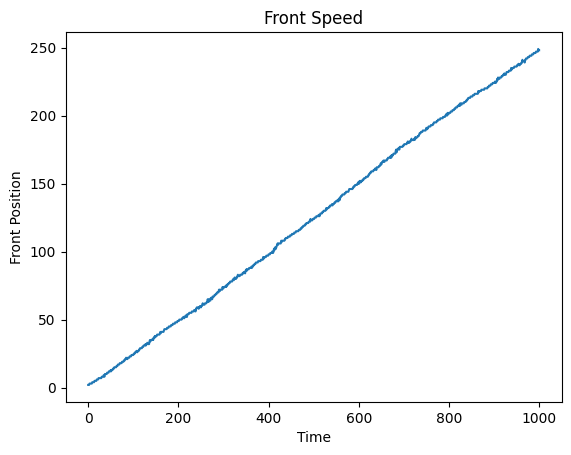

In [ ]:
%matplotlib inline
# Defining the front position as the point where there is 1 cell on average (corresponding to the leading edge)
front_position = np.abs(average_density_avg - 1).argmin(axis=-1).astype(float)

time = np.arange(len(front_position))
plt.xlabel('Time')
plt.ylabel('Front Position')
plt.title('Front Speed')
plt.plot(time, front_position)
plt.show()

The slope of the front position vs. time is the front speed, which evolves linearly indicating that the tumor grows (invades healthy tissue) at a constant speed.

### Front Speed for Different Proliferation Rates

rough idea of the implementation: define a function that does what we have previously done, where it takes a certain value of r_b and calculates the corresponding front speed. in this case, r_b is an array of values, and we want to plot the front speed for each value of r_b.

100%|██████████| 1000/1000 [00:03<00:00, 256.23it/s]


Proliferation rate: 0.02, Front speed: 0.015499566301961512


100%|██████████| 1000/1000 [00:08<00:00, 124.09it/s]


Proliferation rate: 0.04000000000000001, Front speed: 0.03850050548254142


100%|██████████| 1000/1000 [00:04<00:00, 243.61it/s]


...

Proliferation rate: 0.16, Front speed: 0.09247313165876045


100%|██████████| 1000/1000 [00:04<00:00, 249.44it/s]


Proliferation rate: 0.18000000000000002, Front speed: 0.1035686947782756


100%|██████████| 1000/1000 [00:05<00:00, 183.53it/s]


Proliferation rate: 0.2, Front speed: 0.10784560349829814


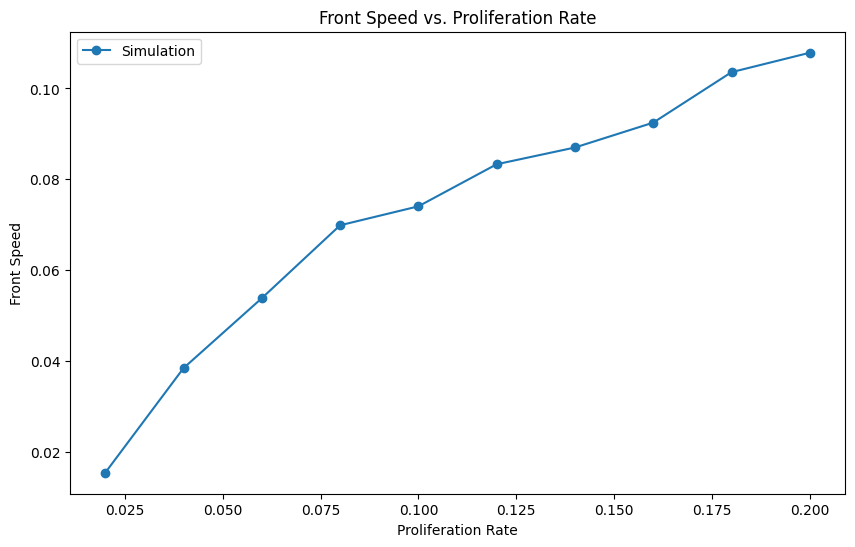

In [ ]:
def calculate_front_speed(r_b):
    #typical lgca implementation
    nodes = np.zeros((400, 20, 5))
    nodes[0:2, 0:21, :] = 1
    lgca = get_lgca(interaction='birthdeath', geometry='square', restchannels=1, nodes=nodes,
                    r_b=r_b, r_d=0.5, bc='refl', dims=(400, 20))
    lgca.interaction = birthdeathae
    #calculating the front speed as done previously
    lgca.timeevo(timesteps=1000, record=True, recorddens=True)
    average_dens = np.mean(lgca.dens_t, axis=-1)
    front_position = np.abs(average_dens - 1).argmin(axis=-1).astype(float)
    time = np.arange(len(front_position))
    return np.polyfit(time, front_position, 1)[0]  # Linear fit, slope is the front speed

#implementation
proliferation_rates = np.linspace(0.1, 2.0, num=10)
front_speeds = []

for r_b in proliferation_rates:
    speed = calculate_front_speed(r_b)
    front_speeds.append(speed)
    print(f'Proliferation rate: {r_b}, Front speed: {speed}')

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(proliferation_rates, front_speeds, 'o-', label='Simulation')
plt.xlabel('Proliferation Rate')
plt.ylabel('Front Speed')
plt.title('Front Speed vs. Proliferation Rate')
plt.legend()
plt.show()

### Front Speed for Different Proliferation Rates (Simulations vs. Theoretical)


100%|██████████| 1000/1000 [00:03<00:00, 264.88it/s]


Proliferation rate: 0.02, Front speed: 0.014436557454521532, Theoretical speed: 0.282842712474619


100%|██████████| 1000/1000 [00:03<00:00, 250.55it/s]


Proliferation rate: 0.04000000000000001, Front speed: 0.03986104913051022, Theoretical speed: 0.4


100%|██████████| 1000/1000 [00:05<00:00, 181.91it/s]


...

Proliferation rate: 0.16, Front speed: 0.09297637691649671, Theoretical speed: 0.8


100%|██████████| 1000/1000 [00:04<00:00, 242.01it/s]


Proliferation rate: 0.18000000000000002, Front speed: 0.10925892071999858, Theoretical speed: 0.8485281374238571


100%|██████████| 1000/1000 [00:04<00:00, 240.48it/s]


Proliferation rate: 0.2, Front speed: 0.11090008195397418, Theoretical speed: 0.8944271909999159


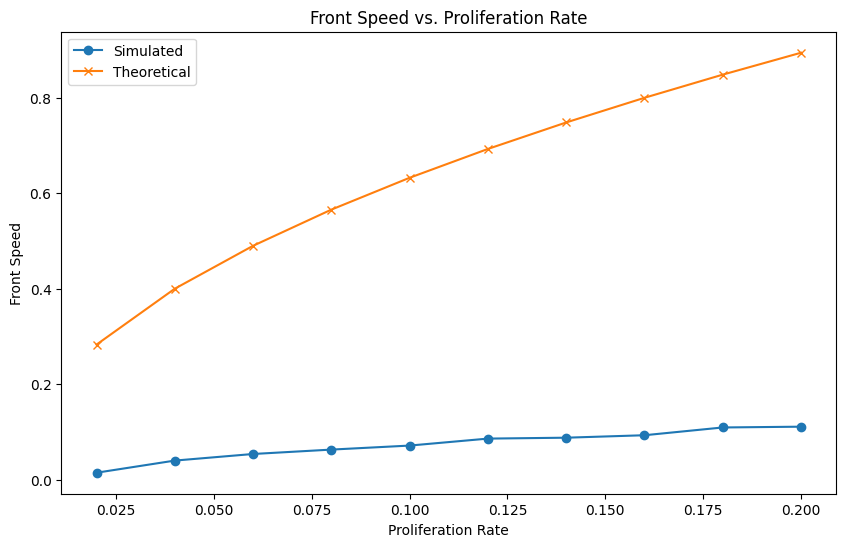

In [ ]:
def calculate_front_speed(r_b):
    #typical lgca implementation
    nodes = np.zeros((400, 20, 5))
    nodes[0:2, 0:21, :] = 1
    lgca = get_lgca(interaction='birthdeath', geometry='square', restchannels=1, nodes=nodes,
                    r_b=r_b, r_d=0.5, bc='refl', dims=(400, 20))
    lgca.interaction = birthdeathae
    #calculating the front speed as done previously
    lgca.timeevo(timesteps=1000, record=True, recorddens=True)
    average_dens = np.mean(lgca.dens_t, axis=-1)
    front_position = np.abs(average_dens - 1).argmin(axis=-1).astype(float)
    time = np.arange(len(front_position))
    return np.polyfit(time, front_position, 1)[0]  # Linear fit, slope is the front speed

proliferation_rates = np.linspace(0.02, 0.2, num=10)
front_speeds = []
theoretical_speeds = []

# Run simulations and calculate front speeds
for r_b in proliferation_rates:
    speed = calculate_front_speed(r_b)
    front_speeds.append(speed)
    theoretical_speeds.append(2 * np.sqrt(r_b))  # Theoretical wave speed
    print(f'Proliferation rate: {r_b}, Front speed: {speed}, Theoretical speed: {2 * np.sqrt(r_b)}')

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(proliferation_rates, front_speeds, 'o-', label='Simulated')
plt.plot(proliferation_rates, theoretical_speeds, 'x-', label='Theoretical')
plt.xlabel('Proliferation Rate')
plt.ylabel('Front Speed')
plt.title('Front Speed vs. Proliferation Rate')
plt.legend()
plt.show()